In [102]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(vegan)
library(compositions)
library(ecodist)
library(ggstatsplot)
library(cowplot)

# File sorting============================================================================================================

In [103]:
# Read taxa data
taxa_tab <- read.table("/ceph/projects/010_SweMaMi/bm.nowak/data/2025-12-09no_minimum_abundance_other_taxa_saliva_taxa_table_cleaned_both_tp.tsv", header = TRUE, sep ="\t", check.names = FALSE, quote='"') 
dim(taxa_tab)
head(taxa_tab)

[1]  846 1673

,11601,921,7766,11497,10644,7547,10048,10681,13611,1054,⋯,19612,17589,18881,21225,20293,21180,21386,21930,17260,18891
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Prevotella_melaninogenica,7.46856,4.43305,2.01303,3.09323,2.18746,2.89516,5.46348,7.60818,2.66597,7.05540,⋯,2.27635,3.91719,0.01522,1.55264,4.93655,6.53807,3.30094,8.66169,3.93085,3.41636
TM7_phylum_sp_oral_taxon_352,3.14409,2.21632,0.27918,0.81149,0.10544,1.92240,1.88095,0.70932,2.10826,1.12378,⋯,2.03540,1.91947,0.99134,2.07174,0.46493,1.60654,3.36108,1.29958,1.20771,1.13150
Veillonella_dispar,3.16098,1.97065,5.15186,5.76151,3.67418,3.17602,4.86584,7.54436,0.60527,13.37827,⋯,2.17340,6.97362,9.72087,7.87567,7.26205,7.27621,5.88949,0.93840,12.13797,1.20559
Streptococcus_salivarius,6.66179,2.07087,9.56769,4.59215,7.84402,12.85163,7.59421,8.05424,0.36229,23.52221,⋯,3.08711,3.59449,18.06276,6.99764,9.51983,2.35358,6.62331,1.23692,12.70253,6.49664
Prevotella_pallens,1.09428,4.69337,0.48324,3.19061,0.00000,0.86855,4.79881,1.50316,1.29621,0.03604,⋯,0.62355,1.68677,0.52037,2.04457,2.32954,3.84069,0.71656,1.85049,1.24524,0.92643
Streptococcus_parasanguinis,5.05936,5.04811,4.55327,3.91857,2.32197,3.38418,3.75756,4.71644,1.78240,11.06978,⋯,1.56545,3.28812,9.99736,7.00401,2.73461,3.21385,7.10522,3.96688,9.57804,1.01967


In [104]:
colnames(taxa_tab) |> head()

[1] "11601" "921"   "7766"  "11497" "10644" "7547"

In [105]:
taxa_tab[, 1] |> head()

[1] 7.46856 3.14409 3.16098 6.66179 1.09428 5.05936

In [106]:
tail(taxa_tab)

,11601,921,7766,11497,10644,7547,10048,10681,13611,1054,⋯,19612,17589,18881,21225,20293,21180,21386,21930,17260,18891
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Brachybacterium_nesterenkovii,0e+00,0e+00,0,0e+00,0,0e+00,0e+00,0e+00,0e+00,0,⋯,0,0,0,0e+00,0e+00,0,0,0e+00,0e+00,0e+00
GGB6673_SGB99879,0e+00,0e+00,0,0e+00,0,0e+00,0e+00,0e+00,0e+00,0,⋯,0,0,0,0e+00,0e+00,0,0,0e+00,0e+00,0e+00
Streptococcus_dysgalactiae,0e+00,0e+00,0,0e+00,0,0e+00,0e+00,0e+00,0e+00,0,⋯,0,0,0,0e+00,0e+00,0,0,0e+00,0e+00,0e+00
Cutibacterium_granulosum,0e+00,0e+00,0,0e+00,0,0e+00,0e+00,0e+00,0e+00,0,⋯,0,0,0,0e+00,0e+00,0,0,0e+00,0e+00,0e+00
Corynebacterium_pseudogenitalium,0e+00,0e+00,0,0e+00,0,0e+00,0e+00,0e+00,0e+00,0,⋯,0,0,0,0e+00,0e+00,0,0,0e+00,0e+00,0e+00
Other_taxa,1e-05,2e-05,0,6e-05,0,8e-05,3e-05,5e-05,2e-05,0,⋯,0,0,0,2e-05,4e-05,0,0,1e-05,1e-05,2e-05


In [107]:
colSums(taxa_tab)

11601      921     7766    11497    10644     7547    10048    10681 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   13611     1054     9284     9482     7776    10343    10351    12972 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   10026    10357    10656     1392    10614    10873    11727     9665 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   10438     7701     1379     1049    11003    10312    11476    11099 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   10791    11667     9418    12715     1060     9290    10982     1152 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   10443     1078     7772     1077    10028    11660     1358    10304 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   11103     9429    11161    10454    11155     7211    11602     1673 
100.0000 100.0000 100.0001 100.0000 100.0001 100.0000 100.0000 100.0000 
   11766     9374     7774    10323    11011    11173     1123     7864 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   11700    10654     9468    10741    10715    10704     1386    10335 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0001 100.0000 
   10064    11482     9298     9288    11157     1079     1094    10020 
100.0000 100.0000 100.0001 100.0000 100.0000 100.0000 100.0000 100.0000 
    9688    10677    21667    17854    21666    18147    18596    17812 
100.0000 100.0000 100.0000 100.0001 100.0000 100.0000 100.0000 100.0000 
   19517    18873    20238    19200    19378    20541    18594    21504 
100.0000 100.0001 100.0000 100.0001 100.0001 100.0000 100.0000 100.0000 
   18855    20407    19422    19351    18605    19254    20046    19310 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   20380    20050    19803    18956    20811    18172    20044    17815 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   18026    18587    18931    20703    20895    18666    20665    19797 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0001 100.0000 100.0000 
   20701    20818    19931    20524    17826    19794    19911    20338 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   20632    19905    20088    20854    19353    20281    21973    17830 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   19283    19193    20451    20420    19964    21132    20308    19190 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0001 
   20068    19338    20248    20226    18708    21634    19881    19493 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   20550    18144    18962    20438    19115    20707    20305    18988 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   18979    11432    23329    23953     9574    23275    10506    22256 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   10432    23353     7231    10488    23562    23298    11390    23603 
100.0000 100.0000 100.0000 100.0000 100.0001 100.0000 100.0000 100.0000 
   10445    10989    22196     9483     7880    11439    20520     1693 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   23349    22327    22308    22142    11364    11212    11182    12952 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0001 100.0000 
   19916    11247    10794    10449    10508    11014    10913    12960 
100.0000 100.0000 100.0000 100.0001 100.0000 100.0000 100.0001 100.0000 
   10434    22269    11419    11054    10469    10771    10520    20523 
100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
   20829    22183    10340    10459    10738    22157     1636    22191 
100.0000 100.0000 100.0000 100.0000 100.0001 100.0000 100.0000 100.0000 
    9921    20850    22176    11060    11384    17794     975

In [108]:
taxa <- as.data.frame(t(taxa_tab))
class(taxa)
head(taxa)

[1] "data.frame"

,Prevotella_melaninogenica,TM7_phylum_sp_oral_taxon_352,Veillonella_dispar,Streptococcus_salivarius,Prevotella_pallens,Streptococcus_parasanguinis,Streptococcus_mitis,Rothia_mucilaginosa,Granulicatella_SGB8255,Veillonella_atypica,⋯,Actinomyces_culturomici,Chryseobacterium_indologenes,Coriobacteriaceae_unclassified_SGB961,Acinetobacter_lwoffii,Brachybacterium_nesterenkovii,GGB6673_SGB99879,Streptococcus_dysgalactiae,Cutibacterium_granulosum,Corynebacterium_pseudogenitalium,Other_taxa
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
11601,7.46856,3.14409,3.16098,6.66179,1.09428,5.05936,0.33502,14.18762,3.57378,2.04531,⋯,0,0,0,0,0,0,0,0,0,1e-05
921,4.43305,2.21632,1.97065,2.07087,4.69337,5.04811,3.80697,7.63255,3.36842,4.51346,⋯,0,0,0,0,0,0,0,0,0,2e-05
7766,2.01303,0.27918,5.15186,9.56769,0.48324,4.55327,19.59795,4.69589,1.17946,2.25569,⋯,0,0,0,0,0,0,0,0,0,0e+00
11497,3.09323,0.81149,5.76151,4.59215,3.19061,3.91857,0.04186,10.82979,0.90467,7.14386,⋯,0,0,0,0,0,0,0,0,0,6e-05
10644,2.18746,0.10544,3.67418,7.84402,0.00000,2.32197,1.28003,9.55203,0.96908,0.71720,⋯,0,0,0,0,0,0,0,0,0,0e+00
7547,2.89516,1.92240,3.17602,12.85163,0.86855,3.38418,2.44921,6.61631,1.34992,4.00314,⋯,0,0,0,0,0,0,0,0,0,8e-05


In [109]:
# Read metadata
combined_meta_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/saliva/tp1_nulliparous/2025-12-09_no_min_abundance_combined_nulliparous_fp_sp_tp1_saliva.csv", header = TRUE, row.names = 1)
head(combined_meta_tp1)
dim(combined_meta_tp1)

,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,Age_groups,Swedish_born,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>
S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,2,1,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
S50f102c,NA,0,0,0,2018-08-05,P50f102c,0,32,3,1,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
S735d77f,NA,0,0,0,2018-08-24,P735d77f,0,25,2,1,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy
S9026714,NA,0,0,2,2019-01-02,P7ece52e,0,25,2,1,⋯,NA,NA,NA,NA,41,Induction,NA,NA,0,First pregnancy
Se5be4e8,NA,0,0,0,2018-07-03,Pbbb08bd,0,33,3,1,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,First pregnancy
Sc9a3575,NA,0,0,0,2018-01-31,Pc9a3575,0,30,3,1,⋯,24,0,0,IUFD Jag fick havandeskapsförgiftning i v.22 och var tvungen att bli igångsatt. Flickan föddes i v. 24 +0 och överlevde tyvärr inte.,24,Induction,NA,NA,1,First pregnancy


[1]  18 565

In [110]:
# Select variables from metadata
variables_tp1 <- combined_meta_tp1 |> 
    select (Group, Q1_Personnummer, age_checked, Age_groups, excess_weight, Weight_before_C, BMI_prior, kit1.salival_sample.barcode, 
            Primipara, Q1_Smoking_checked, Q1_X64_Alcohol_during_pregnancy, Q1_X43.Antibiotics_last_3_months, high_stress_Q1, BMI_now_3_groups) 

In [111]:
dim(variables_tp1)
head(variables_tp1)

[1] 18 14

,Group,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit1.salival_sample.barcode,Primipara,Q1_Smoking_checked,Q1_X64_Alcohol_during_pregnancy,Q1_X43.Antibiotics_last_3_months,high_stress_Q1,BMI_now_3_groups
,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<chr>,<int>,<int>,<int>,<chr>
S39fe1d7,First pregnancy,P3db7da6,29,2,No,55,21,10368,1,"Nej, jag har aldrig rökt",0,0,0,18.5-25 Normal weight
S50f102c,First pregnancy,P50f102c,32,3,No,54,19,10861,1,"Nej, jag har aldrig rökt",0,0,0,18.5-25 Normal weight
S735d77f,First pregnancy,P735d77f,25,2,No,70,24,11161,1,Rökt tidigare,0,0,0,25
S9026714,First pregnancy,P7ece52e,25,2,No,82,27,13593,1,Rökt tidigare,1,0,1,> 25 Overweight
Se5be4e8,First pregnancy,Pbbb08bd,33,3,No,68,21,10856,1,Rökt tidigare,0,0,1,18.5-25 Normal weight
Sc9a3575,First pregnancy,Pc9a3575,30,3,Yes,67,24,1115,1,"Nej, jag har aldrig rökt",0,0,0,25


In [112]:
variables_tp1$Group <- as.factor(variables_tp1$Group)
variables_tp1$kit1.vaginal_sample.barcode <- as.character(variables_tp1$kit1.salival_sample.barcode)
variables_tp1$excess_weight <- as.factor(variables_tp1$excess_weight)
variables_tp1$Q1_X64_Alcohol_during_pregnancy <- as.factor(variables_tp1$Q1_X64_Alcohol_during_pregnancy)
variables_tp1$Q1_X43.Antibiotics_last_3_months <- as.factor(variables_tp1$Q1_X43.Antibiotics_last_3_months)
variables_tp1$high_stress_Q1 <- as.factor(variables_tp1$high_stress_Q1)

In [113]:
head(variables_tp1)

,Group,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit1.salival_sample.barcode,Primipara,Q1_Smoking_checked,Q1_X64_Alcohol_during_pregnancy,Q1_X43.Antibiotics_last_3_months,high_stress_Q1,BMI_now_3_groups,kit1.vaginal_sample.barcode
,<fct>,<chr>,<int>,<int>,<fct>,<int>,<int>,<int>,<int>,<chr>,<fct>,<fct>,<fct>,<chr>,<chr>
S39fe1d7,First pregnancy,P3db7da6,29,2,No,55,21,10368,1,"Nej, jag har aldrig rökt",0,0,0,18.5-25 Normal weight,10368
S50f102c,First pregnancy,P50f102c,32,3,No,54,19,10861,1,"Nej, jag har aldrig rökt",0,0,0,18.5-25 Normal weight,10861
S735d77f,First pregnancy,P735d77f,25,2,No,70,24,11161,1,Rökt tidigare,0,0,0,25,11161
S9026714,First pregnancy,P7ece52e,25,2,No,82,27,13593,1,Rökt tidigare,1,0,1,> 25 Overweight,13593
Se5be4e8,First pregnancy,Pbbb08bd,33,3,No,68,21,10856,1,Rökt tidigare,0,0,1,18.5-25 Normal weight,10856
Sc9a3575,First pregnancy,Pc9a3575,30,3,Yes,67,24,1115,1,"Nej, jag har aldrig rökt",0,0,0,25,1115


In [114]:
# Convert Q1_Smoking_ to categories 
smoking_category <- ifelse(variables_tp1$Q1_Smoking_checked == "Nej, jag har aldrig rökt", 0, 
                           ifelse(variables_tp1$Q1_Smoking_checked == "Rökt tidigare", 0,
                              ifelse(variables_tp1$Q1_Smoking_checked == "Feströkare", 1, NA)))

In [115]:
smoking_category

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [116]:
# Replace column with smoking category
variables_tp1$Q1_Smoking_checked <- as.factor(smoking_category)
variables_tp1$Q1_Smoking_checked
head(variables_tp1)

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
Levels: 0

,Group,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit1.salival_sample.barcode,Primipara,Q1_Smoking_checked,Q1_X64_Alcohol_during_pregnancy,Q1_X43.Antibiotics_last_3_months,high_stress_Q1,BMI_now_3_groups,kit1.vaginal_sample.barcode
,<fct>,<chr>,<int>,<int>,<fct>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<chr>,<chr>
S39fe1d7,First pregnancy,P3db7da6,29,2,No,55,21,10368,1,0,0,0,0,18.5-25 Normal weight,10368
S50f102c,First pregnancy,P50f102c,32,3,No,54,19,10861,1,0,0,0,0,18.5-25 Normal weight,10861
S735d77f,First pregnancy,P735d77f,25,2,No,70,24,11161,1,0,0,0,0,25,11161
S9026714,First pregnancy,P7ece52e,25,2,No,82,27,13593,1,0,1,0,1,> 25 Overweight,13593
Se5be4e8,First pregnancy,Pbbb08bd,33,3,No,68,21,10856,1,0,0,0,1,18.5-25 Normal weight,10856
Sc9a3575,First pregnancy,Pc9a3575,30,3,Yes,67,24,1115,1,0,0,0,0,25,1115


In [117]:
# Group bmi groups
bmi_levels <- c("< 18.5 Underweight", "18.5-25 Normal weight", "> 25 Overweight")
bmi_levels
variables_tp1$BMI_now_3_groups <- factor(variables_tp1$BMI_now_3_groups, levels = bmi_levels)
class(variables_tp1$BMI_now_3_groups)

[1] "< 18.5 Underweight"    "18.5-25 Normal weight" "> 25 Overweight"

[1] "factor"

In [118]:
head(variables_tp1)

,Group,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit1.salival_sample.barcode,Primipara,Q1_Smoking_checked,Q1_X64_Alcohol_during_pregnancy,Q1_X43.Antibiotics_last_3_months,high_stress_Q1,BMI_now_3_groups,kit1.vaginal_sample.barcode
,<fct>,<chr>,<int>,<int>,<fct>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<chr>
S39fe1d7,First pregnancy,P3db7da6,29,2,No,55,21,10368,1,0,0,0,0,18.5-25 Normal weight,10368
S50f102c,First pregnancy,P50f102c,32,3,No,54,19,10861,1,0,0,0,0,18.5-25 Normal weight,10861
S735d77f,First pregnancy,P735d77f,25,2,No,70,24,11161,1,0,0,0,0,NA,11161
S9026714,First pregnancy,P7ece52e,25,2,No,82,27,13593,1,0,1,0,1,> 25 Overweight,13593
Se5be4e8,First pregnancy,Pbbb08bd,33,3,No,68,21,10856,1,0,0,0,1,18.5-25 Normal weight,10856
Sc9a3575,First pregnancy,Pc9a3575,30,3,Yes,67,24,1115,1,0,0,0,0,NA,1115


In [119]:
# Create a table with relevant variables
adonis_tab <- variables_tp1 |> rename(Personalnumber = Q1_Personnummer, Age = age_checked, Sample_ID = kit1.salival_sample.barcode, 
                                      Smoking = Q1_Smoking_checked, Alcohol = Q1_X64_Alcohol_during_pregnancy, Antibiotics = Q1_X43.Antibiotics_last_3_months, 
                                      High_stress =  high_stress_Q1, BMI_groups = BMI_now_3_groups)
head(adonis_tab)

,Group,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Sample_ID,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups,kit1.vaginal_sample.barcode
,<fct>,<chr>,<int>,<int>,<fct>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<chr>
S39fe1d7,First pregnancy,P3db7da6,29,2,No,55,21,10368,1,0,0,0,0,18.5-25 Normal weight,10368
S50f102c,First pregnancy,P50f102c,32,3,No,54,19,10861,1,0,0,0,0,18.5-25 Normal weight,10861
S735d77f,First pregnancy,P735d77f,25,2,No,70,24,11161,1,0,0,0,0,NA,11161
S9026714,First pregnancy,P7ece52e,25,2,No,82,27,13593,1,0,1,0,1,> 25 Overweight,13593
Se5be4e8,First pregnancy,Pbbb08bd,33,3,No,68,21,10856,1,0,0,0,1,18.5-25 Normal weight,10856
Sc9a3575,First pregnancy,Pc9a3575,30,3,Yes,67,24,1115,1,0,0,0,0,NA,1115


In [120]:
# Convert to character and clean whitespace
adonis_tab$Group <- trimws(as.character(adonis_tab$Group))
head(adonis_tab)

,Group,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Sample_ID,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups,kit1.vaginal_sample.barcode
,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<chr>
S39fe1d7,First pregnancy,P3db7da6,29,2,No,55,21,10368,1,0,0,0,0,18.5-25 Normal weight,10368
S50f102c,First pregnancy,P50f102c,32,3,No,54,19,10861,1,0,0,0,0,18.5-25 Normal weight,10861
S735d77f,First pregnancy,P735d77f,25,2,No,70,24,11161,1,0,0,0,0,NA,11161
S9026714,First pregnancy,P7ece52e,25,2,No,82,27,13593,1,0,1,0,1,> 25 Overweight,13593
Se5be4e8,First pregnancy,Pbbb08bd,33,3,No,68,21,10856,1,0,0,0,1,18.5-25 Normal weight,10856
Sc9a3575,First pregnancy,Pc9a3575,30,3,Yes,67,24,1115,1,0,0,0,0,NA,1115


In [121]:
# Rename groups for ease of reading plots
adonis_tab$Group <- ifelse(adonis_tab$Group == "First pregnancy", "Nulliparous", 
                                   ifelse(adonis_tab$Group == "Second pregnancy", "Primiparous", NA))

In [122]:
table(adonis_tab$Group)
#grep("BMI", names(combined_meta_tp1), value =TRUE )


Nulliparous Primiparous 
          9           9 

In [123]:
# Extract barcodes
barcodes <- adonis_tab$Sample_ID
length(barcodes)

[1] 18

In [124]:
taxa_tp1 <- taxa_tab[, colnames(taxa_tab) %in% barcodes]
dim(taxa_tp1)  

[1] 846  18

In [125]:
adonis_tab$Sample_ID
length(unique(rownames(taxa)))

[1] 10368 10861 11161 13593 10856  1115 10654  9864   961 17523 19961 19676
[13] 23292 21011 21973 22236 20818 22000

[1] 1673

In [126]:
# Extraxt taxa TP1
taxa_kit1 <- taxa[rownames(taxa) %in% barcodes, ]
head(taxa_kit1)
dim(taxa_kit1)
#head (taxa)

,Prevotella_melaninogenica,TM7_phylum_sp_oral_taxon_352,Veillonella_dispar,Streptococcus_salivarius,Prevotella_pallens,Streptococcus_parasanguinis,Streptococcus_mitis,Rothia_mucilaginosa,Granulicatella_SGB8255,Veillonella_atypica,⋯,Actinomyces_culturomici,Chryseobacterium_indologenes,Coriobacteriaceae_unclassified_SGB961,Acinetobacter_lwoffii,Brachybacterium_nesterenkovii,GGB6673_SGB99879,Streptococcus_dysgalactiae,Cutibacterium_granulosum,Corynebacterium_pseudogenitalium,Other_taxa
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
11161,8.11658,0.00000,2.77931,12.01375,0.59213,2.94045,4.23281,4.13811,2.06073,2.28192,⋯,0,0,0,0,0,0,0,0,0,0e+00
10654,8.04330,2.08798,6.10340,11.49568,3.60933,6.75227,1.02997,5.23919,2.84020,4.87773,⋯,0,0,0,0,0,0,0,0,0,4e-05
20818,6.71577,5.65761,4.36465,1.46499,2.24977,3.22188,3.03609,5.82578,2.71901,3.09667,⋯,0,0,0,0,0,0,0,0,0,2e-05
21973,1.11156,3.89699,1.36742,2.33622,1.55463,2.14846,5.10771,3.30650,1.11017,3.04727,⋯,0,0,0,0,0,0,0,0,0,1e-05
21011,2.95073,3.86631,3.23901,6.02080,5.19754,1.88701,1.42614,1.36620,0.91845,4.40953,⋯,0,0,0,0,0,0,0,0,0,1e-05
17523,0.32331,1.13414,4.00702,12.01942,0.55079,2.29062,0.56178,1.54239,0.65393,18.26256,⋯,0,0,0,0,0,0,0,0,0,1e-05


[1]  18 846

In [127]:
# Order taxa according to meta data file, so they are in the same order
# Factor to convert rownames and adonis to deffine order

ordered_taxa <- taxa_kit1 |> arrange(factor(rownames(taxa_kit1), level = adonis_tab$Sample_ID))
#adonis_tab$Sample_ID
head(ordered_taxa)
head(adonis_tab$Sample_ID)
dim(adonis_tab)
class((adonis_tab$Sample_ID))

,Prevotella_melaninogenica,TM7_phylum_sp_oral_taxon_352,Veillonella_dispar,Streptococcus_salivarius,Prevotella_pallens,Streptococcus_parasanguinis,Streptococcus_mitis,Rothia_mucilaginosa,Granulicatella_SGB8255,Veillonella_atypica,⋯,Actinomyces_culturomici,Chryseobacterium_indologenes,Coriobacteriaceae_unclassified_SGB961,Acinetobacter_lwoffii,Brachybacterium_nesterenkovii,GGB6673_SGB99879,Streptococcus_dysgalactiae,Cutibacterium_granulosum,Corynebacterium_pseudogenitalium,Other_taxa
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10368,1.25499,4.52168,4.44206,3.57044,5.66783,2.22264,1.92185,2.94159,2.09214,6.97825,⋯,0,0,0,0,0,0,0,0,0,0e+00
10861,1.96059,5.42597,3.73103,10.64857,1.00222,3.12917,1.30890,7.40314,0.72581,4.59387,⋯,0,0,0,0,0,0,0,0,0,0e+00
11161,8.11658,0.00000,2.77931,12.01375,0.59213,2.94045,4.23281,4.13811,2.06073,2.28192,⋯,0,0,0,0,0,0,0,0,0,0e+00
13593,1.71428,3.78259,3.79275,3.82698,1.51265,6.25578,2.28512,2.44977,1.71275,5.32665,⋯,0,0,0,0,0,0,0,0,0,7e-05
10856,4.22536,2.96240,2.74436,5.29482,3.54462,1.86144,0.11018,2.47739,0.33940,5.78762,⋯,0,0,0,0,0,0,0,0,0,1e-05
1115,1.29278,2.46440,2.67129,2.91155,1.90790,4.35493,3.15046,4.61070,1.83738,4.05703,⋯,0,0,0,0,0,0,0,0,0,0e+00


[1] 10368 10861 11161 13593 10856  1115

[1] 18 15

[1] "integer"

In [128]:
adonis_tab$Sample_ID <- as.character(adonis_tab$Sample_ID)
class(adonis_tab$Sample_ID)

[1] "character"

In [129]:
# Check if every ellement matches
all(rownames(ordered_taxa) == adonis_tab$Sample_ID)

[1] TRUE

In [130]:
# Find mismatches
which_mismatch <- which(rownames(ordered_taxa) != adonis_tab$Sample_ID)

# Show the differences
data.frame(
  taxa_row = rownames(ordered_taxa)[which_mismatch],
  metadata_id = adonis_tab$Sample_ID[which_mismatch]
)

taxa_row,metadata_id
<chr>,<chr>


# Jaccard==============================================================================================================

In [131]:
# pa to scale x (taxa?) to presence or absence (1/0) - purpose of Jaccard
# vegdist picks method
jaccard_tp1 <- ordered_taxa |>
    decostand(method = "pa") |>          
  vegdist(method = "jaccard")
head(jaccard_tp1)

[1] 0.4760148 0.5660920 0.4721190 0.5073529 0.4505119 0.4950820

In [132]:
jaccard_pcoa_tp1 <-wcmdscale(jaccard_tp1, eig = TRUE, add = TRUE)
jaccard_points_tp1 <- data.frame(jaccard_pcoa_tp1$points)
head(jaccard_points_tp1)
dim(jaccard_points_tp1)

,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,Dim10,Dim11,Dim12,Dim13,Dim14,Dim15,Dim16,Dim17
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10368,0.09278557,0.02595531,-0.03555431,-0.060939835,-0.06903306,-0.07118229,-0.02288597,0.209625355,-0.02854643,0.17508657,0.02451215,-0.02858009,0.003455939,-0.02706914,0.013225873,-0.014907793,-7.950534e-05
10861,0.13232737,0.06938382,0.23186138,0.018749301,0.01244448,0.09881055,0.03043027,-0.012210502,0.05641846,0.01588170,0.12908968,-0.02913892,-0.073822655,0.05416923,0.008026819,-0.012076564,-3.983295e-02
11161,-0.31568996,0.10606532,0.06975842,0.138480839,-0.03517655,-0.09347215,-0.02244242,-0.009929823,-0.04052417,0.02580769,0.01202857,0.05322857,-0.083099504,0.02624649,-0.041047969,-0.016684255,6.256017e-02
13593,-0.04110955,-0.13296999,-0.17278118,-0.049630335,0.08449009,0.01706192,0.13224957,-0.026554671,0.03744106,0.04332041,0.01697334,0.07391978,-0.065546492,-0.02801401,-0.087956947,0.009804703,-4.078542e-02
10856,-0.04044331,-0.19288631,-0.07810373,-0.006223783,-0.14822778,0.03786005,-0.05476278,-0.177589929,0.02759796,0.11834507,-0.01604014,-0.05678636,0.024220341,0.05991598,0.015807693,0.016242713,7.718784e-03
1115,0.08108591,0.25919904,-0.05482779,0.037387454,0.01440473,0.09079646,0.03734170,0.028222300,-0.04027556,-0.01441822,-0.07466939,-0.08478336,-0.014480664,0.02063028,-0.038359668,0.104386773,1.058386e-02


[1] 18 17

In [133]:
class(rownames(jaccard_points_tp1))

[1] "character"

In [134]:
#jaccard_points_tp1 <- as.character(rownames( jaccard_points_tp1))
#class(rownames(jaccard_points_tp1))

In [135]:
# Merge the points with metadata
jaccard_merged_tp1 <- jaccard_points_tp1 |>
  rownames_to_column(var = "Sample_ID") |>
  left_join(adonis_tab, by = "Sample_ID")
head(jaccard_merged_tp1) 

,Sample_ID,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,⋯,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups,kit1.vaginal_sample.barcode
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<fct>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<chr>
1,10368,0.09278557,0.02595531,-0.03555431,-0.060939835,-0.06903306,-0.07118229,-0.02288597,0.209625355,-0.02854643,⋯,No,55,21,1,0,0,0,0,18.5-25 Normal weight,10368
2,10861,0.13232737,0.06938382,0.23186138,0.018749301,0.01244448,0.09881055,0.03043027,-0.012210502,0.05641846,⋯,No,54,19,1,0,0,0,0,18.5-25 Normal weight,10861
3,11161,-0.31568996,0.10606532,0.06975842,0.138480839,-0.03517655,-0.09347215,-0.02244242,-0.009929823,-0.04052417,⋯,No,70,24,1,0,0,0,0,NA,11161
4,13593,-0.04110955,-0.13296999,-0.17278118,-0.049630335,0.08449009,0.01706192,0.13224957,-0.026554671,0.03744106,⋯,No,82,27,1,0,1,0,1,> 25 Overweight,13593
5,10856,-0.04044331,-0.19288631,-0.07810373,-0.006223783,-0.14822778,0.03786005,-0.05476278,-0.177589929,0.02759796,⋯,No,68,21,1,0,0,0,1,18.5-25 Normal weight,10856
6,1115,0.08108591,0.25919904,-0.05482779,0.037387454,0.01440473,0.09079646,0.03734170,0.028222300,-0.04027556,⋯,Yes,67,24,1,0,0,0,0,NA,1115


In [136]:
jaccard_dim1_tp1 <- round(jaccard_pcoa_tp1$eig[1]/sum(jaccard_pcoa_tp1$eig)*100, digits = 1)
jaccard_dim2_tp1 <- round(jaccard_pcoa_tp1$eig[1]/sum(jaccard_pcoa_tp1$eig)*100, digits = 1)
jaccard_dim1_tp1
jaccard_dim2_tp1

[1] 19.8

[1] 19.8

In [137]:
class(jaccard_merged_tp1$Group)
table(jaccard_merged_tp1$Group)
dim(jaccard_merged_tp1)

[1] "character"


Nulliparous Primiparous 
          9           9 

[1] 18 32

Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


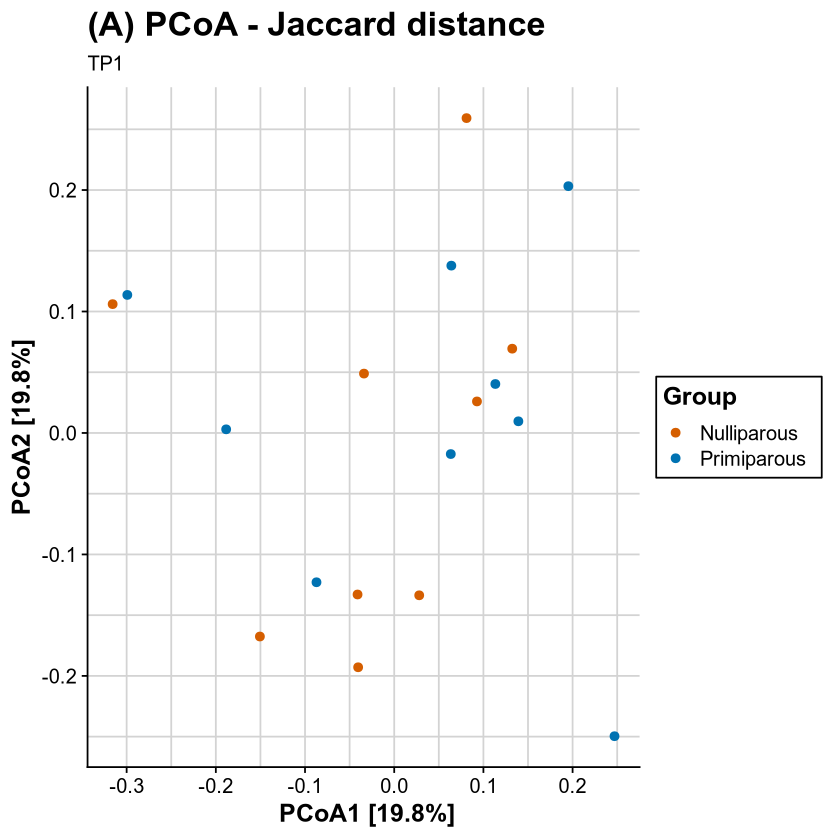

In [138]:
dye <- c("Nulliparous" = "#D55E00", "Primiparous" = "#0072B2")

jaccard_plot <- jaccard_merged_tp1 |>
    ggplot(aes(x = Dim1, y = Dim2, colour = Group)) +
    geom_point() +
    labs(
        y = paste0("PCoA2 [", jaccard_dim2_tp1, "%]"),
        x = paste0(" PCoA1 [", jaccard_dim1_tp1, "%]"),
        title = "(A) PCoA - Jaccard distance",
        subtitle = "TP1"
    ) +
    scale_colour_manual(values = dye) +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color = "Black", size = 0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
         axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
)
jaccard_plot

## PERMANOVA ----------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [139]:
set.seed(123)
adonis_Group <- adonis2(formula = jaccard_tp1 ~ Group, na.action = na.omit, data = adonis_tab)
# adonis_Group
# Rename "Model" to say Group, for better orientation
rownames(adonis_Group)[1] <- "Group"
adonis_Group
jaccard_pval <- adonis_Group[1, "Pr(>F)"]
jaccard_pval

jaccard_r2 <- adonis_Group[1, "R2"]
jaccard_r2

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group,1,0.07776989,0.03556761,0.5900691,0.963
Residual,16,2.10876720,0.96443239,NA,NA
Total,17,2.18653710,1.00000000,NA,NA


[1] 0.963

[1] 0.03556761

In [140]:
adonis_Age <- adonis2(formula = jaccard_tp1 ~ Age , na.action = na.omit, data = adonis_tab)
# Rename "Model" for better orientation
rownames(adonis_Age)[1] <- "Age"
adonis_Age

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age,1,0.2140799,0.09790819,1.736554,0.028
Residual,16,1.9724572,0.90209181,NA,NA
Total,17,2.1865371,1.00000000,NA,NA


In [141]:
adonis_Agegroup <- adonis2(formula = jaccard_tp1 ~ Age_groups , na.action = na.omit, data = adonis_tab)
# Rename "Model" for better orientation
rownames(adonis_Agegroup)[1] <- "Age_group"
adonis_Agegroup

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age_group,1,0.2109268,0.09646612,1.708246,0.032
Residual,16,1.9756103,0.90353388,NA,NA
Total,17,2.1865371,1.00000000,NA,NA


In [142]:
adonis_BMI <- adonis2(formula = jaccard_tp1 ~ BMI_prior, na.action = na.omit, data = adonis_tab)
rownames(adonis_BMI)[1] <- "BMI_prior"
adonis_BMI

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BMI_prior,1,0.1890807,0.08647496,1.514572,0.064
Residual,16,1.9974564,0.91352504,NA,NA
Total,17,2.1865371,1.00000000,NA,NA


In [143]:
adonis_bmigroups <- adonis2(formula = jaccard_tp1 ~ BMI_groups, na.action = na.omit, data = adonis_tab)
# Rename "Model" for better orientation
rownames(adonis_bmigroups)[1] <- "BMI_groups"
adonis_bmigroups

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BMI_groups,1,0.1915647,0.1148155,1.556495,0.027
Residual,12,1.4768924,0.8851845,NA,NA
Total,13,1.6684570,1.0000000,NA,NA


# Aitchison=========================================================================================================

## Robust Aitchison

In [144]:
aitchison <- ordered_taxa |>
   as.matrix() |>
    vegdist(method = "robust.aitchison")
head(aitchison)
head(as.matrix(aitchison))

[1]  7.857114 29.801719 11.390951 18.406011 16.451841 26.083358

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
1,0.000000,7.857114,29.80172,11.39095,18.40601,16.45184,26.08336,11.05992,10.817369,12.993849,11.49449,35.021283,16.81103,5.927535,7.749772,23.56935,4.981704,10.35209
2,7.857114,0.000000,28.78414,16.65691,25.52811,10.55649,30.36928,11.13085,7.024296,20.113861,9.84149,33.014824,17.61856,7.675855,10.392551,24.37902,9.321842,7.81579
3,29.801719,28.784138,0.00000,28.03603,35.59608,34.22119,34.00704,19.60754,31.228999,32.628985,21.12444,6.254919,18.89155,34.415518,33.063121,23.26897,28.016228,21.06918
4,11.390951,16.656913,28.03603,0.00000,10.68433,26.90972,14.84779,11.45192,15.551099,6.567355,12.44132,33.620137,11.18312,14.909816,18.699742,15.32283,7.448396,15.32440
5,18.406011,25.528109,35.59608,10.68433,0.00000,34.84731,15.01167,21.39810,24.838204,5.438505,22.90886,41.581698,20.74201,21.499089,23.818981,23.04356,16.496094,24.85248
6,16.451841,10.556489,34.22119,26.90972,34.84731,0.00000,40.90819,20.32820,15.667433,29.442609,19.25695,37.512983,27.33508,14.835278,13.246018,34.31036,19.523751,15.47313


In [145]:
# Convert to matrix and re-assign proper row and column names since they did not transfer properly
aitchison_matrix <- as.matrix(aitchison)
rownames(aitchison_matrix) <- rownames(ordered_taxa)
colnames(aitchison_matrix) <- rownames(ordered_taxa)
head(aitchison_matrix)

,10368,10861,11161,13593,10856,1115,10654,9864,961,17523,19961,19676,23292,21011,21973,22236,20818,22000
10368,0.000000,7.857114,29.80172,11.39095,18.40601,16.45184,26.08336,11.05992,10.817369,12.993849,11.49449,35.021283,16.81103,5.927535,7.749772,23.56935,4.981704,10.35209
10861,7.857114,0.000000,28.78414,16.65691,25.52811,10.55649,30.36928,11.13085,7.024296,20.113861,9.84149,33.014824,17.61856,7.675855,10.392551,24.37902,9.321842,7.81579
11161,29.801719,28.784138,0.00000,28.03603,35.59608,34.22119,34.00704,19.60754,31.228999,32.628985,21.12444,6.254919,18.89155,34.415518,33.063121,23.26897,28.016228,21.06918
13593,11.390951,16.656913,28.03603,0.00000,10.68433,26.90972,14.84779,11.45192,15.551099,6.567355,12.44132,33.620137,11.18312,14.909816,18.699742,15.32283,7.448396,15.32440
10856,18.406011,25.528109,35.59608,10.68433,0.00000,34.84731,15.01167,21.39810,24.838204,5.438505,22.90886,41.581698,20.74201,21.499089,23.818981,23.04356,16.496094,24.85248
1115,16.451841,10.556489,34.22119,26.90972,34.84731,0.00000,40.90819,20.32820,15.667433,29.442609,19.25695,37.512983,27.33508,14.835278,13.246018,34.31036,19.523751,15.47313


In [146]:
aitchison_pcoa <- wcmdscale(aitchison_matrix, eig = TRUE)
aitchison_points <- data.frame(aitchison_pcoa$points)
head(aitchison_points)
aitchison_merged <- aitchison_points |>
  rownames_to_column(var = "Sample_ID") |>
  left_join(adonis_tab, by = "Sample_ID")
head(aitchison_merged)

,Dim1,Dim2,Dim3
,<dbl>,<dbl>,<dbl>
10368,-7.698908,2.461243,-2.427784
10861,-5.657631,8.282403,2.438583
11161,21.902224,4.700486,-5.054802
13593,-2.885307,-7.769202,-1.041781
10856,-7.437407,-15.358786,-7.027722
1115,-8.741771,18.351572,1.704158


,Sample_ID,Dim1,Dim2,Dim3,Group,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups,kit1.vaginal_sample.barcode
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<chr>
1,10368,-7.698908,2.461243,-2.427784,Nulliparous,P3db7da6,29,2,No,55,21,1,0,0,0,0,18.5-25 Normal weight,10368
2,10861,-5.657631,8.282403,2.438583,Nulliparous,P50f102c,32,3,No,54,19,1,0,0,0,0,18.5-25 Normal weight,10861
3,11161,21.902224,4.700486,-5.054802,Nulliparous,P735d77f,25,2,No,70,24,1,0,0,0,0,NA,11161
4,13593,-2.885307,-7.769202,-1.041781,Nulliparous,P7ece52e,25,2,No,82,27,1,0,1,0,1,> 25 Overweight,13593
5,10856,-7.437407,-15.358786,-7.027722,Nulliparous,Pbbb08bd,33,3,No,68,21,1,0,0,0,1,18.5-25 Normal weight,10856
6,1115,-8.741771,18.351572,1.704158,Nulliparous,Pc9a3575,30,3,Yes,67,24,1,0,0,0,0,NA,1115


In [147]:
#head(aitchison_pcoa)

In [148]:
nrow(ordered_taxa)
length(aitchison_pcoa$eig)
eig_vals <- aitchison_pcoa$eig
# How many non-zero eigenvalues?
sum(eig_vals > 1e-6)  # Threshold to count "non-zero" dimensions

# Show all eigenvalues
eig_vals

[1] 18

[1] 3

[1] 3

[1] 1971.6004 1619.4739  328.3849

In [149]:
# Save the eigenvalues, add percentages for plot
aitchison_dim1 <- round(aitchison_pcoa$eig[1]/sum(aitchison_pcoa$eig)*100, digits = 1)
aitchison_dim2 <- round(aitchison_pcoa$eig[2]/sum(aitchison_pcoa$eig)*100,  digits = 1)
aitchison_dim1
aitchison_dim2

[1] 50.3

[1] 41.3

In [150]:
aitchison_dim3 <- round(aitchison_pcoa$eig[3]/sum(aitchison_pcoa$eig)*100, digits = 1)
aitchison_dim4 <- round(aitchison_pcoa$eig[4]/sum(aitchison_pcoa$eig)*100,  digits = 1)
aitchison_dim3
aitchison_dim4

[1] 8.4

[1] NA

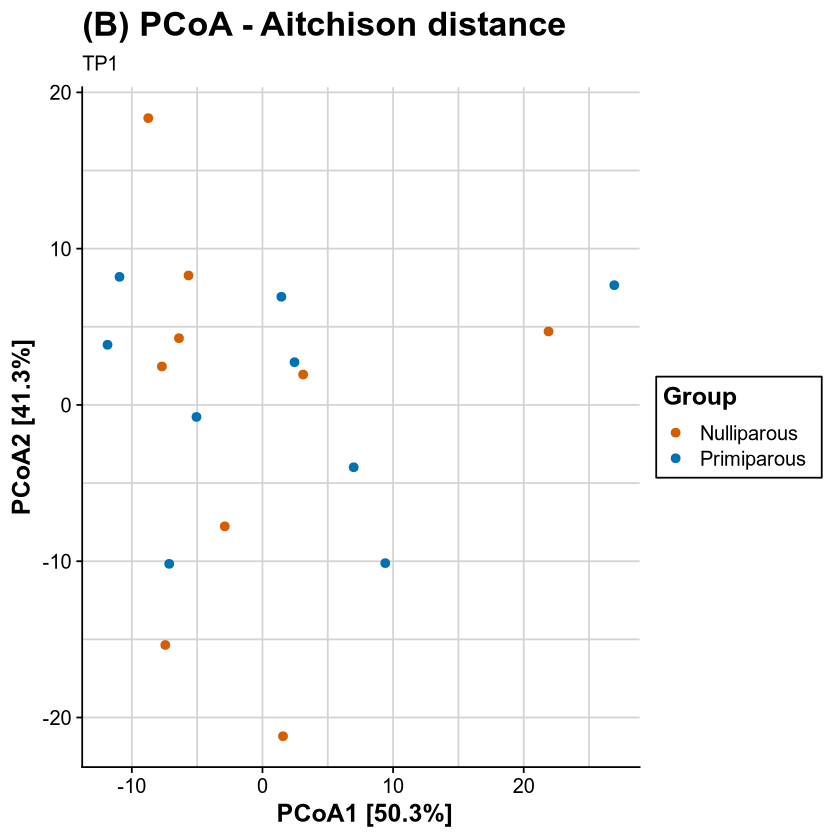

In [151]:
aitchison_plot <- aitchison_merged |>
    ggplot(aes(x = Dim1, y = Dim2, colour = Group)) +
    geom_point() +
    labs(
        y = paste0("PCoA2 [", aitchison_dim2, "%]"),
        x = paste0(" PCoA1 [", aitchison_dim1, "%]"),
        title = "(B) PCoA - Aitchison distance",
        subtitle = "TP1"
    ) +
    scale_colour_manual(values = dye) +
    theme_half_open() +
    #background_grid() +
    theme(
        legend.box.background = element_rect(color="Black", size=0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
)
    
aitchison_plot

## PERMANOVA ----------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [152]:
set.seed(123)
adonis_ait_Group <- adonis2(formula = aitchison  ~ Group, na.action = na.omit, data = adonis_tab)
rownames(adonis_ait_Group)[1] <- "Group"
adonis_ait_Group
aitchison_pval <- adonis_ait_Group[1, "Pr(>F)"]
aitchison_pval

aitchison_r2 <- adonis_ait_Group[1, "R2"]
aitchison_r2

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group,1,37.32981,0.009524225,0.1538529,0.899
Residual,16,3882.12946,0.990475775,NA,NA
Total,17,3919.45928,1.000000000,NA,NA


[1] 0.899

[1] 0.009524225

In [153]:
adonis_ait_Age <- adonis2(formula = aitchison  ~ Age, na.action = na.omit, data = adonis_tab)
rownames(adonis_ait_Age)[1] <- "Age"
adonis_ait_Age

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age,1,585.956,0.1494992,2.812445,0.058
Residual,16,3333.503,0.8505008,NA,NA
Total,17,3919.459,1.0000000,NA,NA


In [154]:
adonis_ait_bmigroups <- adonis2(formula = aitchison ~ BMI_groups, na.action = na.omit, data = adonis_tab)
rownames(adonis_ait_bmigroups)[1] <- "BMI_groups"
adonis_ait_bmigroups

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BMI_groups,1,266.3793,0.1205609,1.645061,0.233
Residual,12,1943.1199,0.8794391,NA,NA
Total,13,2209.4992,1.0000000,NA,NA


In [155]:
adonis_ait_group_bmigroups <- adonis2(formula = aitchison ~ Group + BMI_groups, na.action = na.omit, data = adonis_tab)
rownames(adonis_ait_group_bmigroups)[1] <- "Group_bmi_groups"
adonis_ait_group_bmigroups

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_bmi_groups,2,323.9981,0.1466387,0.9451012,0.446
Residual,11,1885.5011,0.8533613,NA,NA
Total,13,2209.4992,1.0000000,NA,NA


# Bray curtis=======================================================================================================================================

In [156]:
bray_curt_dist <- vegdist(ordered_taxa, method = "bray")
head(as.matrix(bray_curt_dist))

,10368,10861,11161,13593,10856,1115,10654,9864,961,17523,19961,19676,23292,21011,21973,22236,20818,22000
10368,0.0000000,0.4184697,0.6425361,0.3882385,0.4463699,0.3999848,0.4351278,0.4766675,0.4183557,0.4678188,0.4383758,0.6076970,0.4193687,0.3209087,0.4242037,0.5267327,0.3977784,0.4793688
10861,0.4184697,0.0000000,0.5272704,0.4053011,0.4766162,0.3908111,0.4322128,0.4790795,0.3834229,0.4603138,0.2647793,0.6036731,0.3648348,0.4513501,0.4375348,0.3633857,0.4156105,0.4080540
11161,0.6425361,0.5272704,0.0000000,0.6338135,0.6806031,0.5984322,0.5155530,0.5424492,0.4992620,0.6697822,0.4984156,0.2966702,0.5184913,0.6593889,0.6320905,0.5177835,0.5440314,0.4810442
13593,0.3882385,0.4053011,0.6338135,0.0000000,0.4582099,0.4256534,0.4067732,0.5109555,0.4036464,0.5168495,0.4172216,0.6498313,0.2993140,0.4373876,0.4707237,0.4390346,0.4355181,0.4917566
10856,0.4463699,0.4766162,0.6806031,0.4582099,0.0000000,0.5589791,0.4213305,0.5623388,0.4826354,0.5332698,0.4249377,0.7020185,0.4365307,0.4615981,0.5812924,0.5152595,0.5509356,0.5545915
1115,0.3999848,0.3908111,0.5984322,0.4256534,0.5589791,0.0000000,0.4991543,0.4602734,0.4373041,0.6119901,0.4762162,0.5516784,0.4363837,0.4474592,0.2653937,0.5550942,0.4184621,0.4502817


In [157]:
bray_curt_pcoa <- pco(bray_curt_dist)
#head(bray_curt_pcoa)

In [158]:
bray_vect <- bray_curt_pcoa$vectors
bray_curt_merged <- bray_vect |>
    rownames_to_column(var= "Sample_ID") |>
    left_join(adonis_tab, by = "Sample_ID")
head(bray_curt_merged)

,Sample_ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,⋯,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups,kit1.vaginal_sample.barcode
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<fct>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<chr>
1,10368,0.150737360,-0.12494347,0.073095127,-0.088228894,0.05565612,-0.001412183,-0.063786821,0.06873914,0.04432507,⋯,No,55,21,1,0,0,0,0,18.5-25 Normal weight,10368
2,10861,0.057019807,0.01811306,-0.007332946,0.180035704,-0.06448661,0.003798186,-0.079700380,-0.01776331,-0.09019446,⋯,No,54,19,1,0,0,0,0,18.5-25 Normal weight,10861
3,11161,-0.358099557,0.12367582,0.159150069,-0.007243540,-0.08465480,-0.036526711,0.008293933,-0.05115684,-0.04476851,⋯,No,70,24,1,0,0,0,0,NA,11161
4,13593,0.147502240,-0.03217950,-0.081410055,-0.008628735,-0.08970217,-0.159560035,0.073293156,-0.00039012,0.13659578,⋯,No,82,27,1,0,1,0,1,> 25 Overweight,13593
5,10856,0.206836528,0.06640345,-0.024285274,-0.167566212,-0.17984927,0.181816504,0.046107221,0.04285716,-0.04571110,⋯,No,68,21,1,0,0,0,1,18.5-25 Normal weight,10856
6,1115,-0.001913403,-0.25051591,-0.005607248,0.076794812,0.02223290,-0.042149199,0.115758368,0.06204877,-0.09210877,⋯,Yes,67,24,1,0,0,0,0,NA,1115


In [159]:
bray_curt_df <- data.frame(Sample_ID = bray_curt_merged[,1],
                          Group = bray_curt_merged$Group,
                           pcoa1 = bray_curt_merged[,2],
                           pcoa2 = bray_curt_merged[,3],
                           pcoa3 = bray_curt_merged[,4]
                          )
head(bray_curt_df)

,Sample_ID,Group,pcoa1,pcoa2,pcoa3
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,10368,Nulliparous,0.150737360,-0.12494347,0.073095127
2,10861,Nulliparous,0.057019807,0.01811306,-0.007332946
3,11161,Nulliparous,-0.358099557,0.12367582,0.159150069
4,13593,Nulliparous,0.147502240,-0.03217950,-0.081410055
5,10856,Nulliparous,0.206836528,0.06640345,-0.024285274
6,1115,Nulliparous,-0.001913403,-0.25051591,-0.005607248


In [160]:
# Save the eigenvalues, add percentages for plot
bray_dim1 <- round(bray_curt_pcoa$values[1]/sum(bray_curt_pcoa$values)*100, digits = 1)
bray_dim2 <- round(bray_curt_pcoa$values[2]/sum(bray_curt_pcoa$values)*100,  digits = 1)
bray_dim2
bray_dim1

[1] 18.9

[1] 26.3

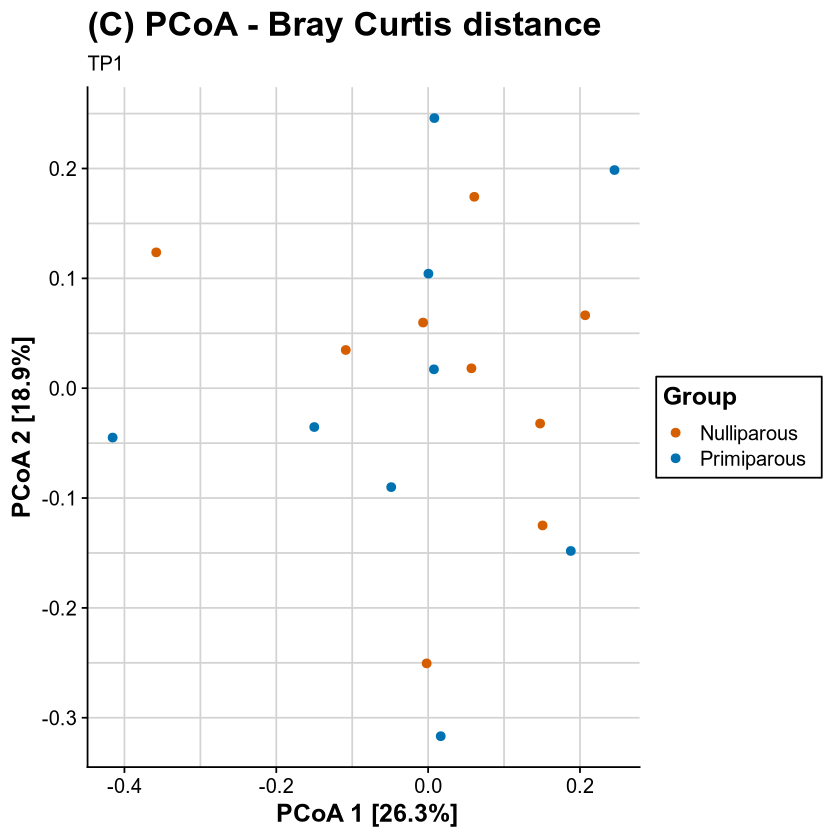

In [161]:
bray_plot <- bray_curt_df |>
    ggplot(aes(x = pcoa1, y = pcoa2, color = Group)) +
    geom_point() +
    labs(
        x = paste0(" PCoA 1 [", bray_dim1, "%]"),
        y = paste0("PCoA 2 [", bray_dim2, "%]"),
        title = "(C) PCoA - Bray Curtis distance",
        subtitle = "TP1"
    ) +
    scale_color_manual(values = dye) +
    theme_half_open() +
    theme( 
        legend.box.background = element_rect(color="Black", size=0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
     )

bray_plot

## PERMANOVA ----------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [162]:
set.seed(123)
adonis_bray_Group <- adonis2(formula = bray_curt_dist ~ Group, na.action = na.omit, data = adonis_tab)
rownames(adonis_bray_Group)[1] <- "Group"
adonis_bray_Group
bray_pval <- adonis_bray_Group[1, "Pr(>F)"]
bray_pval

bray_r2 <- adonis_bray_Group[1, "R2"]
bray_r2

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group,1,0.06464587,0.03224872,0.5331737,0.918
Residual,16,1.93995660,0.96775128,NA,NA
Total,17,2.00460247,1.00000000,NA,NA


[1] 0.918

[1] 0.03224872

In [163]:
adonis_bray_Age <- adonis2(formula = bray_curt_dist ~ Age, na.action = na.omit, data = adonis_tab)
rownames(adonis_bray_Age)[1] <- "Age"
adonis_bray_Age
#head(adonis_tab)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age,1,0.1920666,0.09581282,1.695451,0.068
Residual,16,1.8125359,0.90418718,NA,NA
Total,17,2.0046025,1.00000000,NA,NA


In [164]:
adonis_bray_bmigroups <- adonis2(formula = bray_curt_dist ~ BMI_groups, na.action = na.omit, data = adonis_tab)
rownames(adonis_bray_bmigroups)[1] <- "BMI_groups"
adonis_bray_bmigroups

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BMI_groups,1,0.149141,0.09881027,1.315731,0.17
Residual,12,1.360227,0.90118973,NA,NA
Total,13,1.509368,1.00000000,NA,NA


In [165]:
adonis_bray_group_bmi <- adonis2(formula = bray_curt_dist ~ Group + BMI_prior, na.action = na.omit, data = adonis_tab)
rownames(adonis_bray_group_bmi)[1] <- "Group_bmi"
adonis_bray_group_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_bmi,2,0.2716384,0.1355073,1.175609,0.265
Residual,15,1.7329641,0.8644927,NA,NA
Total,17,2.0046025,1.0000000,NA,NA


In [166]:
adonis_bray_age_bmi <- adonis2(formula = bray_curt_dist ~ Age + BMI_prior, na.action = na.omit, data = adonis_tab)
rownames(adonis_bray_age_bmi)[1] <- "Age_bmi"
adonis_bray_age_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age_bmi,2,0.2947529,0.1470381,1.292889,0.143
Residual,15,1.7098496,0.8529619,NA,NA
Total,17,2.0046025,1.0000000,NA,NA


In [167]:
adonis_bray_agegroup_bmi <- adonis2(formula = bray_curt_dist ~ Age_groups + BMI_prior, na.action = na.omit, data = adonis_tab)
rownames(adonis_bray_agegroup_bmi)[1] <- "AgeGroups_bmi"
adonis_bray_agegroup_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AgeGroups_bmi,2,0.2891434,0.1442398,1.264137,0.182
Residual,15,1.7154591,0.8557602,NA,NA
Total,17,2.0046025,1.0000000,NA,NA


In [168]:
adonis_bray_agegroup_weight <- adonis2(formula = bray_curt_dist ~ Age_groups + Weight_before_C, na.action = na.omit, data = adonis_tab)
rownames(adonis_bray_agegroup_weight)[1] <- "AgeGroups_weightBefore"
adonis_bray_agegroup_weight

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AgeGroups_weightBefore,2,0.2741016,0.1367361,1.187958,0.253
Residual,15,1.7305009,0.8632639,NA,NA
Total,17,2.0046025,1.0000000,NA,NA


# Combined plots ------------------------------------------------------------------------------------------

In [169]:
class(jaccard_plot) 

[1] "ggplot2::ggplot" "ggplot"          "ggplot2::gg"     "S7_object"      
[5] "gg"

In [170]:
# Extract legend from bray plot
legend_bray <- get_legend(bray_plot)

In [171]:
# remove legends so only one remains
plot_jaccard_nl <- jaccard_plot +  guides(fill = "none", color = "none") 
plot_aitch_nl <- aitchison_plot +  guides(fill = "none", color = "none") 
plot_bray_nl <- bray_plot +  guides(fill = "none", color = "none") 

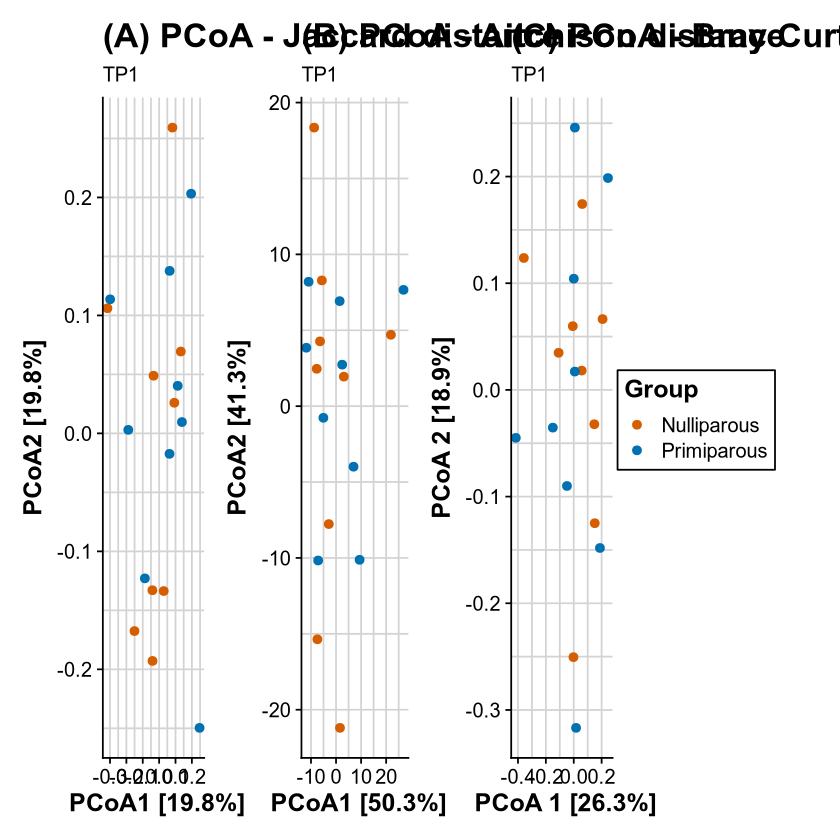

In [172]:

combined_plot <- plot_grid(plot_jaccard_nl, plot_aitch_nl, plot_bray_nl, nrow =1) 

combined_plot_legend <- plot_grid(plot_jaccard_nl, plot_aitch_nl, plot_bray_nl, legend_bray, nrow =1) 

final_plot <- ggdraw(combined_plot_legend) +
  theme_half_open() +
  background_grid() +
  theme(
    axis.text.x = element_blank(),
    plot.title = element_text(size = 15),
    axis.title = element_text(size = 15)
  )
final_plot


In [173]:
#ggsave(file = paste0(Sys.Date(), "_saliva_beta_tp1.pdf"), path ="/ceph/projects/010_SweMaMi/bm.nowak/plot_output/", 
 #      plot = final_plot, width = 19, height = 8)

# Exporting data===============================================================================

In [174]:
#write.csv(jaccard_merged, file = paste0("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp1_nulliparous/tp1_alpha_beta_diversity/beta/", Sys.Date(), 
 #                                       "_jaccard_merged_tp1", ".csv"), row.names = FALSE)

#write.csv(aitchison_merged, file = paste0("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp1_nulliparous/tp1_alpha_beta_diversity/beta/", Sys.Date(), 
 #                                       "_aitchison_merged_tp1", ".csv"), row.names = FALSE)

#write.csv(bray_curt_merged, file = paste0("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp1_nulliparous/tp1_alpha_beta_diversity/beta/", Sys.Date(), 
                                      #  "_bray_curt_df_tp1", ".csv"), row.names = FALSE)

# Bar plots -----------------------------------------------------------------------------

In [175]:
bar_df <- data.frame(
    Distance_metrics = c("Jaccard", "Aitchison", "Bray_Curtis"),
    Pvalue = c(jaccard_pval, aitchison_pval, bray_pval),
    R2 = c(jaccard_r2, aitchison_r2, bray_r2)
)
bar_df

Distance_metrics,Pvalue,R2
<chr>,<dbl>,<dbl>
Jaccard,0.963,0.035567608
Aitchison,0.899,0.009524225
Bray_Curtis,0.918,0.032248723


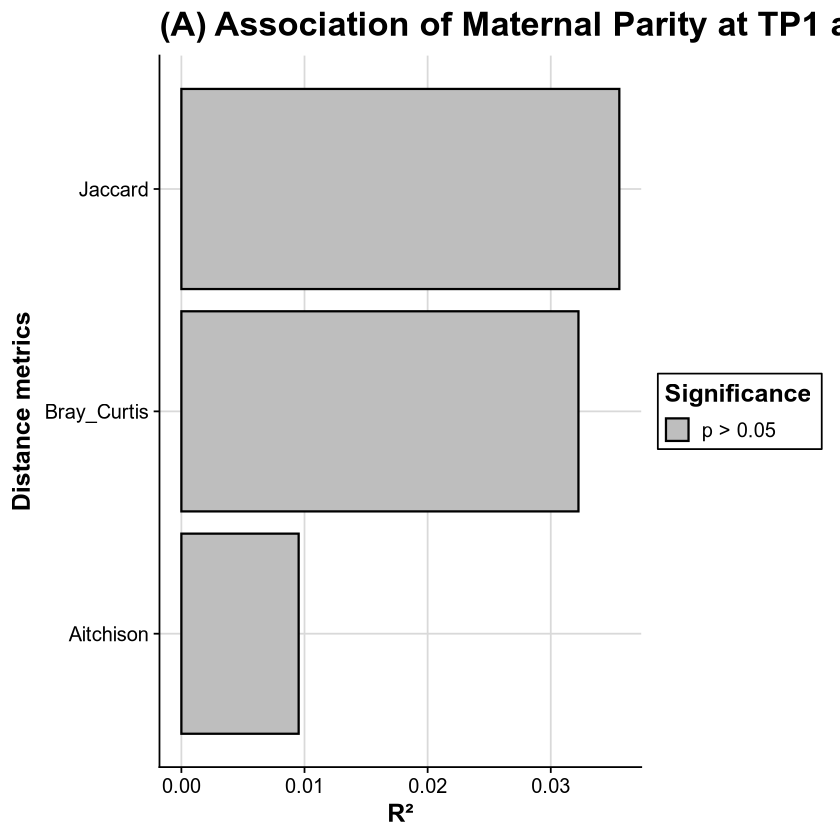

In [176]:
# Create column specifying p value greater or lesser
bar_df$Significance <- factor(ifelse(bar_df$Pvalue < 0.05, "p ≤ 0.05", "p > 0.05"))
dye_pval <- c("p ≤ 0.05" = "#0072B2", "p > 0.05" = "grey") # color vector 

#names(dye_pval) <- bar_df$Distance

bar_plot <- bar_df |>
    ggplot(aes(x = R2, y = Distance_metrics, fill = Significance)) +
    geom_col(colour = "black") +
    scale_fill_manual(values = dye_pval) +
    labs(title = "(A) Association of Maternal Parity at TP1 across Distance Metrics for the Saliva Microbiome",
        x = "R²",
        y = "Distance metrics") +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color="Black", size=0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")) +
    background_grid()

bar_plot

In [177]:
#ggsave(file = paste0(Sys.Date(), "_saliva_beta_tp1_bar.pdf"), path ="/ceph/projects/010_SweMaMi/bm.nowak/plot_output/", 
 #      plot = bar_plot, width = 14, height = 8)